# 📘 Домашнє завдання №16. Прогнозування часових рядів

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW16


# 📊 Дані

## 1. Датасет для ARIMA (без сезонності)

```python
import numpy as np
import pandas as pd

np.random.seed(42)

n = 200
time = np.arange(n)

trend = 0.1 * time
noise = np.random.normal(0, 1, n)

values = trend + noise

dates = pd.date_range(start='2020-01-01', periods=n, freq='D')

df_arima = pd.DataFrame({
    'ds': dates,
    'y': values
})
```

---

## 2. Датасет для SARIMA / ML / Prophet (із сезонністю)

```python
np.random.seed(42)

n = 240
time = np.arange(n)

trend = 0.05 * time
seasonality = 10 * np.sin(2 * np.pi * time / 12)
noise = np.random.normal(0, 2, n)

values = trend + seasonality + noise

dates = pd.date_range(start='2015-01-01', periods=n, freq='M')

df_seasonal = pd.DataFrame({
    'ds': dates,
    'y': values
})
```


# 🧠 Завдання

## 🔹 Завдання 1. Аналіз і візуалізація

Для обох датасетів:

1. Побудувати графік часового ряду
2. Побудувати:

   * ACF
   * PACF
3. Зробити висновки:

   * чи є тренд
   * чи є сезонність
   * який можливий період сезонності

---

## 🔹 Завдання 2. Побудова моделей

### 📌 2.1 ARIMA (для df_arima)

1. Перевірити стаціонарність (ADF тест)
2. При необхідності зробити диференціювання
3. Визначити параметри:

   * вручну через ACF/PACF
   * автоматично через auto_arima
4. Натренувати модель
5. Зробити прогноз

---

### 📌 2.2 SARIMA (для df_seasonal)

1. Визначити сезонність (період m)
2. Використати auto_arima (з seasonal=True)
3. Натренувати модель
4. Побудувати прогноз

---

### 📌 2.3 Prophet (для df_seasonal)

1. Переконатися, що дані мають формат:

   * ds — дата
   * y — значення

2. Натренувати модель:

```python
from prophet import Prophet

model = Prophet()
model.fit(df_seasonal)
```

3. Створити майбутні дати:

```python
future = model.make_future_dataframe(periods=24, freq='M')
```

4. Побудувати прогноз:

```python
forecast = model.predict(future)
```

5. Побудувати графіки:

* прогнозу
* компонентів (trend, seasonality)

---

### 📌 2.4 ML модель (для df_seasonal)

Обрати одну модель:

* XGBoost / RandomForest / CatBoost

1. Створити фічі:

   * lag_1, lag_2, lag_12
   * rolling статистики
   * календарні фічі (місяць, рік)

2. Розбити дані на train/test

3. Натренувати модель

4. Побудувати прогноз

---

## 🔹 Завдання 3. Візуальна оцінка

Для кожної моделі:

1. Побудувати графік:

   * train
   * test
   * forecast

2. Оцінити:

   * чи модель ловить тренд
   * чи модель ловить сезонність
   * чи є систематичні помилки

---

## 🔹 Завдання 4. Оцінка якості

Для кожної моделі обчислити:

* MAE
* RMSE
* MAPE

Порівняти:

* ARIMA (manual vs auto)
* SARIMA vs Prophet
* Prophet vs ML


In [1]:
# TODO: uncommit
# # Silent installation or update
#
# # Clean cache
# !python3 -m pip cache purge -q
#
# # Force updating
# package_update = [
#     "pip",
#     "scikit-learn",
# ]
#
# for package_name in package_update:
#     !bash -c "python3 -m pip install -U '{package_name}' -q"
#
# # Install missing packages
# package_array = [
#     "jinja2",
#     "ipywidgets",
#     "nbformat",
#     "kagglehub[pandas-datasets]",
#     "numpy",
#     "pandas",
#     "matplotlib",
#     "scipy",
#     "statsmodels",
# ]
#
# for package_name in package_array:
#     !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# TODO: uncommit
# # Synchronization with remote source
#
# import shutil
# from pathlib import Path
#
# # Input data
# hm_version = 16
#
# # Solution
# git_project_url = f"https://github.com/BogdanPinchuk/DataScience-PBY_HW{hm_version}.git"
# main_file_name = f"Bohdan_Pinchuk_DS_HW{hm_version}.ipynb"
#
# # upload all files
# current_path = !pwd
# current_path = current_path[0]
# parent_path = !dirname "$current_path"
# parent_path = parent_path[0]
# temp_path = f"{parent_path}/temp"
#
# # Clone data
# !rm -rf "$temp_path"
# !git clone "$git_project_url" "$temp_path"
#
# source = Path(temp_path)
# destination = Path(current_path)
# exclude = {main_file_name, ".git", ".idea"}
#
# for item in source.iterdir():
#     if item.name in exclude:
#         continue
#
#     target = destination / item.name
#     if item.is_dir():
#         shutil.copytree(item, target, dirs_exist_ok=True)
#     else:
#         shutil.copy2(item, target)
#
# # Clean temp folder
# !rm -rf "$temp_path"

## ✳️ Підготовка датасетів

In [3]:
# Data synthesis - Датасет для ARIMA

import numpy as np
import pandas as pd
from IPython.display import display

# Input data
rng_seed = 42
n = 200

# Solution
np.random.seed(rng_seed)

time = np.arange(n)
trend = 0.1 * time
noise = np.random.normal(0, 1, n)
values = trend + noise
dates = pd.date_range(start='2020-01-01', periods=n, freq='D')

# створюємо DataFrame
ds_arima_name = "ARIMA (без сезонності)"
df_arima = pd.DataFrame({
    'ds': dates,
    'y': values,
})

# Print results
display(df_arima)

,ds,y
0,2020-01-01,0.496714
1,2020-01-02,-0.038264
2,2020-01-03,0.847689
3,2020-01-04,1.823030
4,2020-01-05,0.165847
...,...,...
195,2020-07-14,19.885317
196,2020-07-15,18.716143
197,2020-07-16,19.853725
198,2020-07-17,19.858209


In [4]:
# Data synthesis - Датасет для SARIMA

import numpy as np
import pandas as pd
from IPython.display import display

# Input data
rng_seed = 42
n = 240

# Solution
np.random.seed(rng_seed)

time = np.arange(n)
trend = 0.05 * time
seasonality = 10 * np.sin(2 * np.pi * time / 12)
noise = np.random.normal(0, 2, n)
values = trend + seasonality + noise
dates = pd.date_range(start='2015-01-01', periods=n, freq='MS')  # початок кожного місяця

# створюємо DataFrame
ds_seasonal_name = "SARIMA / ML / Prophet (із сезонністю)"
df_seasonal = pd.DataFrame({
    'ds': dates,
    'y': values,
})

# Print results
display(df_seasonal)

,ds,y
0,2015-01-01,0.993428
1,2015-02-01,4.773471
2,2015-03-01,10.055631
3,2015-04-01,13.196060
4,2015-05-01,8.391947
...,...,...
235,2034-08-01,8.017838
236,2034-09-01,-0.910539
237,2034-10-01,2.222909
238,2034-11-01,1.916173


## ✅ Рішення 1

Для обох датасетів:

1. Побудувати графік часового ряду
2. Побудувати:

   * ACF
   * PACF
3. Зробити висновки:

   * чи є тренд
   * чи є сезонність
   * який можливий період сезонності

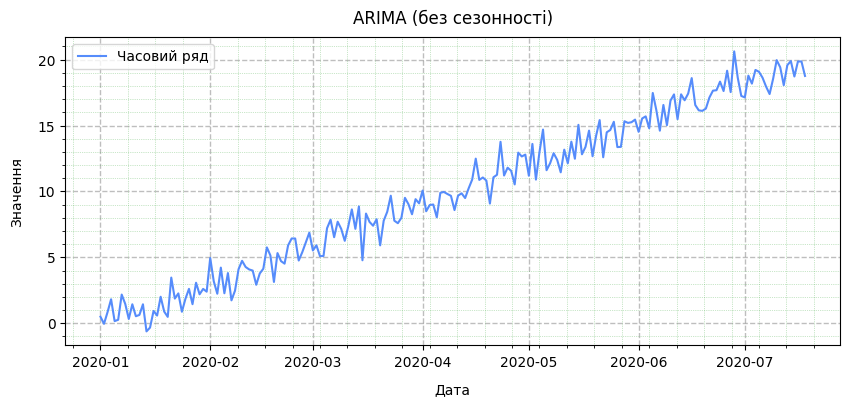

In [5]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_set = df_arima

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(data_set["ds"], data_set["y"], label="Часовий ряд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title(ds_arima_name, pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

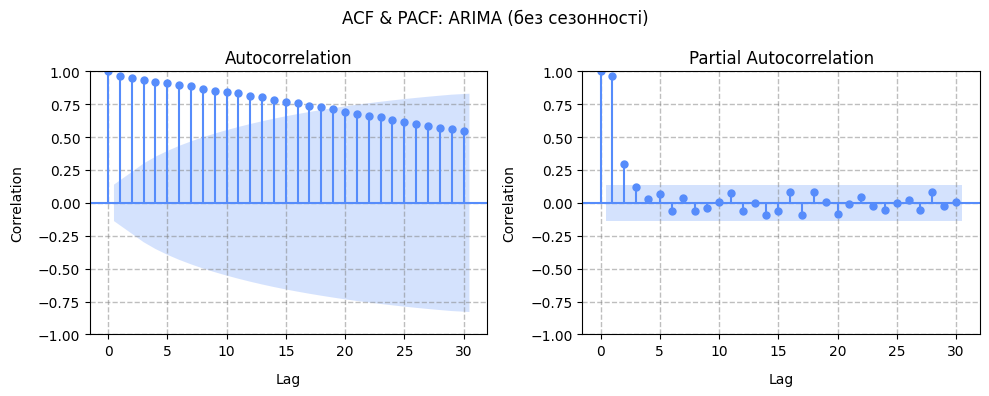

In [6]:
# Graphic results

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Input data
lags = 30
data_set = df_arima["y"]

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax = axes[0]
plot_acf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

ax = axes[1]
plot_pacf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

plt.suptitle(f"ACF & PACF: {ds_arima_name}")

plt.tight_layout()
plt.show()

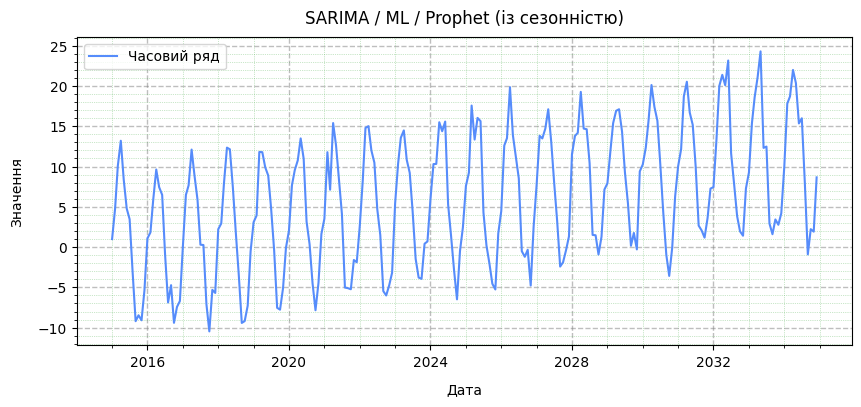

In [7]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_set = df_seasonal

# Solution
_, ax = plt.subplots(figsize=(10, 4))

ax.plot(data_set["ds"], data_set["y"], label="Часовий ряд")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title(ds_seasonal_name, pad=10, loc='center', color='black')
ax.set_xlabel("Дата", labelpad=10, loc='center', color='black')
ax.set_ylabel("Значення", labelpad=10, loc='center', color='black')
ax.legend()

plt.show()

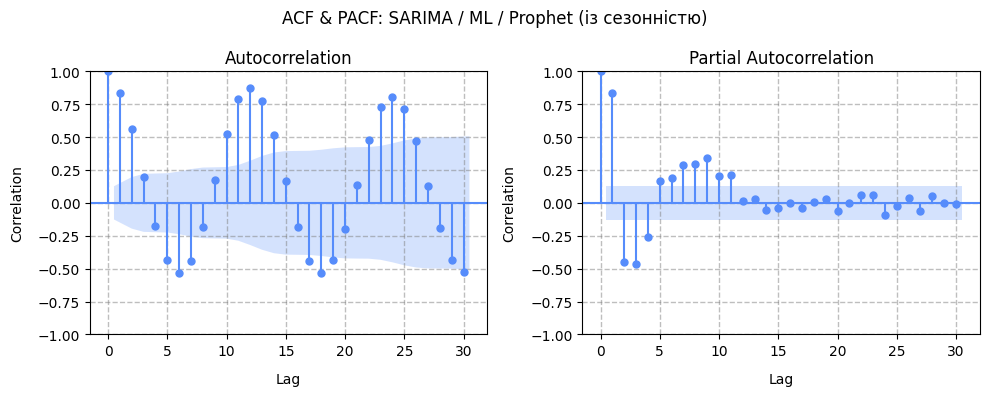

In [8]:
# Graphic results

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Input data
lags = 30
data_set = df_seasonal["y"]

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax = axes[0]
plot_acf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

ax = axes[1]
plot_pacf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

plt.suptitle(f"ACF & PACF: {ds_seasonal_name}")

plt.tight_layout()
plt.show()

* **ACF** — (автокореляція) відображає прямий і непрямий звʼязок із лагами.
* **PACF** — (часткова кореляція) відображає тільки прямий звʼязок із лагами.

Параметр    | графік ACF                 | графік PACF
------------|----------------------------|------------
AR(p)       | Затихає плавно             | Обривається різко на p лагу
MA(q)       | Обривається різко на q лагу | Затихає плавно

- **d** — кількість диференціювань до досягнення стаціонарності ряду.
- **p** — індекс лагу, на якому обірвався **PACF** графік на стаціонарному ряді.
- **q** — індекс лагу, на якому обірвався **ACF** графік на стаціонарному ряді.

Висновок. Датасет для ARIMA — за графіком ACF згасає плавно, а отже, це авторегресія і немає стаціонарності, і є тренд. Датасет для SARIMA —— за графіком ACF має гармонічну форму з повільним, плавним згасанням, а отже, він немає стаціонарності, а має тренд і сезонність, а період сезонності можна визначити за кількістю лагів між піками.

## ✅ Рішення 2.1

Для обох датасетів:

1. Перевірити стаціонарність (ADF тест)
2. При необхідності зробити диференціювання
3. Визначити параметри:

   * вручну через ACF/PACF
   * автоматично через auto_arima
4. Натренувати модель
5. Зробити прогноз

In [9]:
import numpy as np
import apps.main as mn
import apps.reporter as rpt
from IPython.core.display import Markdown
from statsmodels.tsa.stattools import adfuller

# Input data

# Solution
d_ar = 0
p_value_ar = adfuller(df_arima["y"])[1]  # type: ignore
stat_ar = mn.is_stationary(p_value_ar)

rp_ar = rpt.Reporter()
rp_ar.tolerance = 4
rp_ar.add_item("Стаціонарність початкових даних", 'так' if stat_ar else 'ні')
if p_value_ar < np.power(10.0, -rp_ar.tolerance):
    rp_ar.add_item("Початкове p-value", f"{p_value_ar:.{rp_ar.tolerance}e}")
else:
    rp_ar.add_item("Початкове p-value", rp_ar.format_value(p_value_ar))

if not stat_ar:
    stat_ar, d_ar, p_value_ar, output_ar = mn.find_stationarity(df_arima["y"].values)

    rp_ar.add_item("Досягнуто стаціонарності", 'так' if stat_ar else 'ні')
    if p_value_ar < np.power(10.0, -rp_ar.tolerance):
        rp_ar.add_item("Отримане p-value", f"{p_value_ar:.{rp_ar.tolerance}e}")
    else:
        rp_ar.add_item("Отримане p-value", rp_ar.format_value(p_value_ar))

rp_ar.add_item("Параметр інтегрованості, d", str(d_ar))

d_s = 0
p_value_s = adfuller(df_seasonal["y"])[1]  # type: ignore
stat_s = mn.is_stationary(p_value_s)

rp_s = rpt.Reporter()
rp_s.tolerance = 4
rp_s.add_item("Стаціонарність початкових даних", 'так' if stat_s else 'ні')
if p_value_s < np.power(10.0, -rp_s.tolerance):
    rp_s.add_item("Початкове p-value", f"{p_value_s:.{rp_s.tolerance}e}")
else:
    rp_s.add_item("Початкове p-value", rp_s.format_value(p_value_s))

if not stat_s:
    stat_s, d_s, p_value_s, output_s = mn.find_stationarity(df_seasonal["y"].values)

    rp_s.add_item("Досягнуто стаціонарності", 'так' if stat_s else 'ні')
    if p_value_s < np.power(10.0, -rp_s.tolerance):
        rp_s.add_item("Отримане p-value", f"{p_value_s:.{rp_s.tolerance}e}")
    else:
        rp_s.add_item("Отримане p-value", rp_s.format_value(p_value_s))

rp_s.add_item("Параметр інтегрованості, d", str(d_s))

# Print results
display(Markdown(f"### {ds_arima_name}"))
rp_ar.print_pd_report()
display(Markdown(f"### {ds_seasonal_name}"))
rp_s.print_pd_report()


### ARIMA (без сезонності)

Attribute,Result
Стаціонарність початкових даних,ні
Початкове p-value,0.9525
Досягнуто стаціонарності,так
Отримане p-value,1.6789e-11
"Параметр інтегрованості, d",1


### SARIMA / ML / Prophet (із сезонністю)

Attribute,Result
Стаціонарність початкових даних,ні
Початкове p-value,0.9387
Досягнуто стаціонарності,так
Отримане p-value,2.6649e-22
"Параметр інтегрованості, d",1


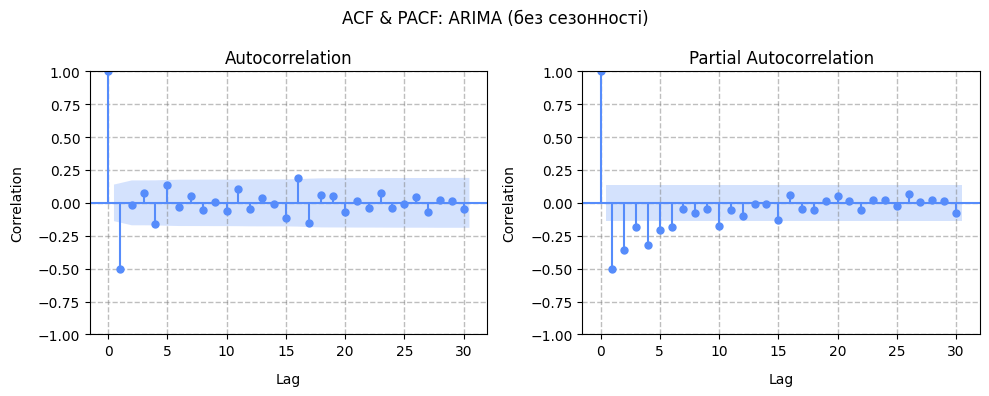

In [10]:
# Graphic results

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Input data
lags = 30
data_set = output_ar

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax = axes[0]
plot_acf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

ax = axes[1]
plot_pacf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

plt.suptitle(f"ACF & PACF: {ds_arima_name}")

plt.tight_layout()
plt.show()

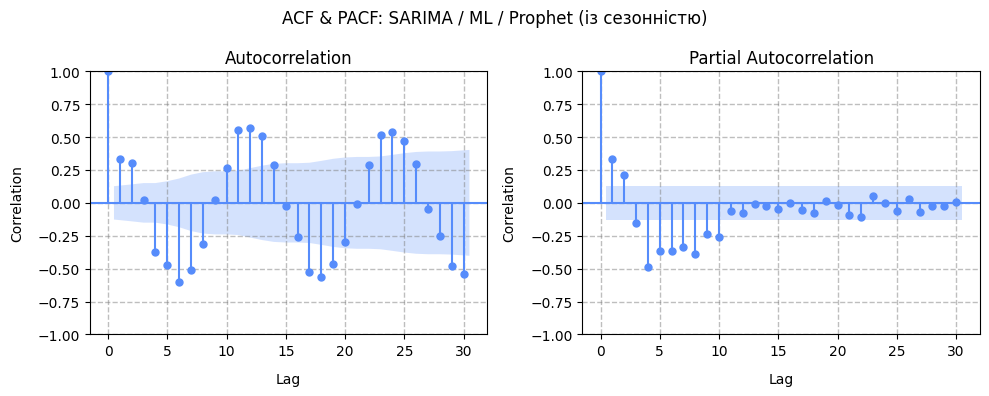

In [11]:
# Graphic results

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Input data
lags = 30
data_set = output_s

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

ax = axes[0]
plot_acf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

ax = axes[1]
plot_pacf(data_set, lags=lags, ax=ax)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_xlabel("Lag", labelpad=10, loc='center', color='black')
ax.set_ylabel("Correlation", labelpad=10, loc='center', color='black')

plt.suptitle(f"ACF & PACF: {ds_seasonal_name}")

plt.tight_layout()
plt.show()

Висновок. За допомогою диференціювання було видалено тренди, але тест Дікі-Фуллера не виявляє сезонність і не забезпечує повної стаціонарності.

In [15]:
import apps.main as mn
import apps.reporter as rpt

# Input data
data_set = output_ar

# Solution

# знаходження q вручну
q_ar = mn.find_q_acf_manually(data_set)
p_ar = mn.find_p_pacf_manually(data_set)

rp = rpt.Reporter()
rp.add_item("Ковзного середнього параметр, p", str(p_ar))
rp.add_item("Авторегресійний параметр, q", str(q_ar))
rp.add_item("Інтегрованості параметр, d", str(d_ar))
rp.add_item("Структура ARIMA: (p, q, d)", f"({p_ar}, {q_ar}, {d_ar})")

# Print results
rp.print_pd_report(ds_arima_name)

Attribute,Result
"Ковзного середнього параметр, p",6
"Авторегресійний параметр, q",1
"Інтегрованості параметр, d",1
"Структура ARIMA: (p, q, d)","(6, 1, 1)"
